In [21]:
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt

In [22]:
url = "https://raw.githubusercontent.com/mirea-aie-2025/aie-course-meta/main/seminars/S05/S05-hw-dataset.csv"

df = pd.read_csv(url)

In [23]:
df.head()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [25]:
df.describe()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


In [26]:
df['default'].value_counts(normalize=True)

default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

В датасете 3000 объектов и 17 признаков. Очевидной аномалией является отрицательный минмиальный баланс. Таргет распределен следующим образом: 41.03% дефолт, 58.97% нет дефолта

In [27]:
target_column = 'default'
X = df.drop(columns=['client_id', target_column])
y = df[target_column]
non_numeric_cols = X.select_dtypes(include=['object', 'category']).columns
print(X.head())

   age  income  years_employed  credit_score  debt_to_income  \
0   25   94074              22           839        0.547339   
1   58   51884              26           565        0.290882   
2   53   48656              39           561        0.522340   
3   42   81492              30           582        0.709123   
4   42   94713               8           642        0.793392   

   num_credit_cards  num_late_payments  has_mortgage  has_car_loan  \
0                 1                  7             0             0   
1                 1                  1             0             1   
2                 1                 13             0             0   
3                 2                 10             1             1   
4                 3                  3             0             0   

   savings_balance  checking_balance  region_risk_score  \
0            26057              5229           0.080052   
1            16221             11595           0.428311   
2            5544

In [28]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          
    random_state=42,      
    stratify=y             
)

In [29]:
baseline_mf = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_mf.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,42
,constant,None


In [30]:
y_pred_mf = baseline_mf.predict(X_test)
y_proba_mf = baseline_mf.predict_proba(X_test)[:, 1]

accuracy_mf = accuracy_score(y_test, y_pred_mf)
roc_auc_mf = roc_auc_score(y_test, y_proba_mf)

print(f"Accuracy:  {accuracy_mf:.4f} ({accuracy_mf*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc_mf:.4f}")
print(f"\n{classification_report(y_test, y_pred_mf)}")

Accuracy:  0.5900 (59.00%)
ROC-AUC:   0.5000

              precision    recall  f1-score   support

           0       0.59      1.00      0.74       354
           1       0.00      0.00      0.00       246

    accuracy                           0.59       600
   macro avg       0.29      0.50      0.37       600
weighted avg       0.35      0.59      0.44       600



C:\Users\dimas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dimas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dimas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

В данном случае бейзлайн предсказывает мажоритарный класс, accuracy равен доле этого класса, а roc-auc показывает, что модель не научилась предсказывать классы лучше случайного угадывания. 

In [31]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'logreg__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear']
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,                    # 5-fold кросс-валидация
    scoring='roc_auc',       # оптимизируем ROC-AUC
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Лучшие параметры: {'logreg__C': 0.1, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}
Лучший ROC-AUC (CV): 0.8609


In [32]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print(f"\nConfusion Matrix:")
print(conf_matrix)
print(f"TN={conf_matrix[0,0]}, FP={conf_matrix[0,1]}")
print(f"FN={conf_matrix[1,0]}, TP={conf_matrix[1,1]}")

print(classification_report(y_test, y_pred))

Accuracy:  0.8033 (80.33%)
ROC-AUC:   0.8765
Precision: 0.7963
Recall:    0.6992
F1-Score:  0.7446

Confusion Matrix:
[[310  44]
 [ 74 172]]
TN=310, FP=44
FN=74, TP=172
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       354
           1       0.80      0.70      0.74       246

    accuracy                           0.80       600
   macro avg       0.80      0.79      0.79       600
weighted avg       0.80      0.80      0.80       600



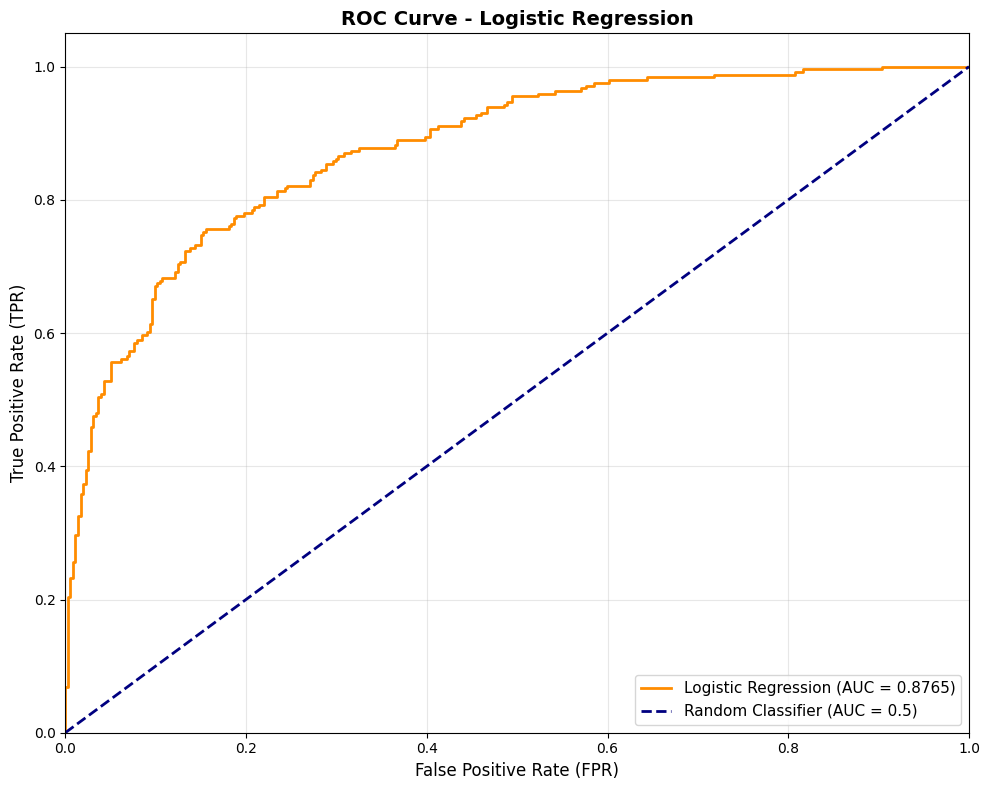

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Logistic Regression (AUC = {roc_auc_value:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

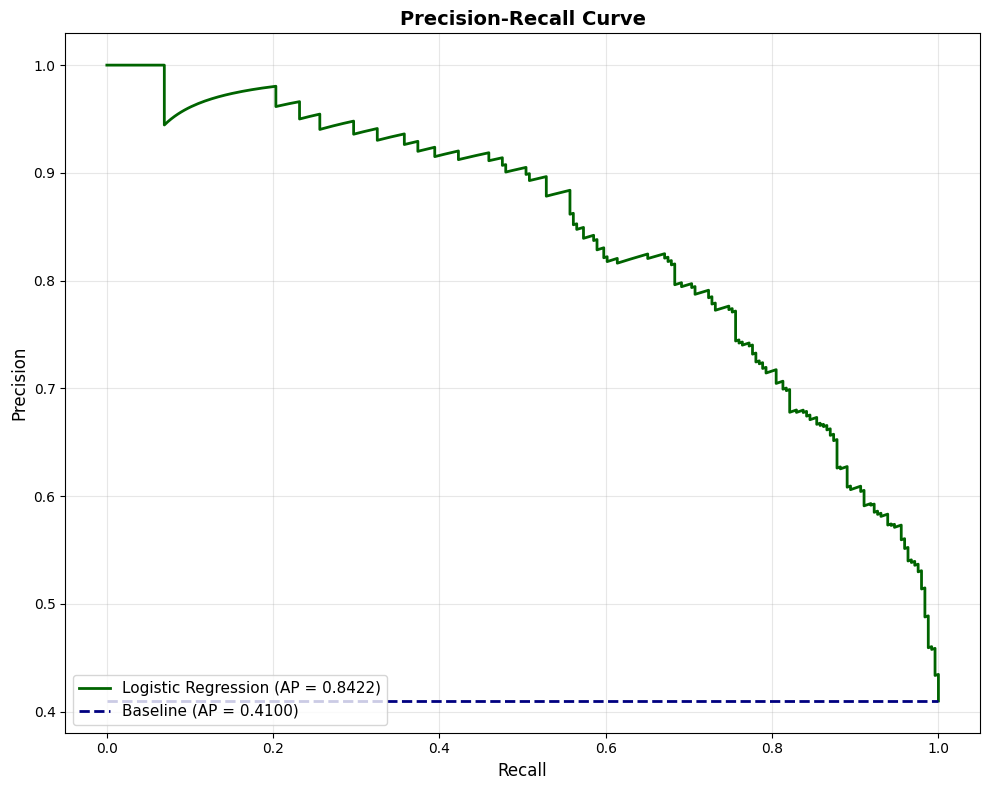

In [36]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(10, 8))
plt.plot(recall_curve, precision_curve, color='darkgreen', lw=2,
         label=f'Logistic Regression (AP = {avg_precision:.4f})')

baseline = y_test.mean()
plt.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--',
         label=f'Baseline (AP = {baseline:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()